# DS150 | Module 2 Activity 1
<span style="color:Orange;"> Group 6 Members: </span>  
Aguaviva, Christopher  
Baluyot, Kent  
Berida, Ronabelle  


***

#### <span style="color:Orange;">  Table of Contents: </span>

I. Executive Summary

II. Problem Statement

III. Motivations

IV. Data Preparation

V. Exploratory Data Analysis
  
VI. Result and discussion

VII. Conclusion and Recommendations

***

## <span style="color:Orange;"> I. Executive Summary </span>

The analysis delved into a dataset concerning taxi rides, employing Python libraries like Pandas, Matplotlib, and Seaborn for data manipulation and exploratory data analysis (EDA). Initial steps involved data preparation, including column renaming, datetime conversion, and feature selection. EDA revealed insights into the distribution of numerical features like fare amount, mileage, and ride duration, while visualizations such as histograms and box plots aided in understanding variable distributions and relationships. Outliers were identified and removed from certain variables to ensure data integrity, and correlation analysis highlighted relationships between features. The analysis culminated in a pairplot visualization, offering a comprehensive view of pairwise relationships among key variables. Overall, the exploration provided valuable insights into the characteristics and relationships within the taxi ride dataset, aiding in further understanding and analysis.


## <span style="color:Orange;">  II. Problem Statement </span>

Despite the ubiquity of taxi services, optimizing operational efficiency and customer satisfaction remains a challenge for taxi providers. The problem at hand is to leverage data-driven insights to enhance the performance and service quality of taxi operations. This entails understanding the factors influencing key metrics such as fare amount, mileage, and ride duration, as well as identifying opportunities for improvement in service delivery. By addressing these challenges, the goal is to maximize revenue, minimize operational costs, and ultimately enhance the overall customer experience. Therefore, the objective of this analysis is to identify patterns, trends, and correlations within the taxi ride dataset, leading to actionable recommendations for improving operational efficiency and customer satisfaction in the taxi service industry.


## <span style="color:Orange;"> III. Motivation </span>

The motivation behind this analysis stems from the increasing demand for efficient and customer-centric taxi services in urban environments. Taxi providers face numerous challenges in meeting these demands, including optimizing route planning, managing fleet operations, and ensuring customer satisfaction. By leveraging data-driven insights, we aim to address these challenges and drive improvements in operational efficiency and service quality. Understanding the underlying patterns and correlations within the taxi ride dataset can unlock valuable insights into factors affecting key metrics such as fare amount, mileage, and ride duration. These insights can inform strategic decision-making, enabling taxi providers to enhance route optimization, allocate resources effectively, and deliver personalized experiences to customers. Ultimately, the motivation is to harness the power of data analytics to transform taxi services, providing a seamless and enjoyable transportation experience for passengers while maximizing profitability for providers.



***

Importing Modules and Initiliazing a Class

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 40)   # displays max columns of the DataFrame 
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
# for print content visualizations
class colors:
    GREEN = '\033[92m'
    RED = '\033[91m'
    END = '\033[0m'


## <span style="color:Orange;"> IV. Data Preparation </span>


As the data is too large for the interpreter to handle, we decided to create a list and divide the dataset into chunks of data. At the end, the data in the list are concatenated together and transformed into a DataFrame format. This method is to ensure faster and more efficient storage of data.

In [4]:
# Dividing the dataset into chunks of data and then combining it
path = "C:/Users/User/Documents/taxi_final.csv"    # replace the path if the taxi_final.csv is in another folder

data_chunks = []
chunksize = 50000       # Specify chunksize (number of rows to read at a time)

for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
    data_chunks.append(chunk)

df = pd.concat(data_chunks, ignore_index=True)

In [6]:
# Seeing the numerical details of a numerical dtype column
num_dtype_col = ['FareAmount', 'GratuityAmount', 'SurchargeAmount', 'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'Milage', 'Duration']
subset_df = df[num_dtype_col]
subset_df.describe()

,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,Milage,Duration
count,1.187299e+07,1.179124e+07,1.179111e+07,1.179111e+07,1.179111e+07,1.192407e+07,1.183018e+07,1.157841e+07
mean,1.279349e+01,1.432134e+00,2.482045e-01,6.006939e-01,4.384362e-03,1.653235e+01,1.531396e+01,7.935440e+02
std,1.610088e+02,1.275516e+02,8.639809e-02,1.123405e+00,2.574233e+00,1.106130e+03,2.543766e+02,1.255415e+05
min,-3.456100e+02,-4.640000e+00,-9.950000e+01,-5.390000e+02,-1.500000e+00,-5.325300e+02,-1.580700e+02,-1.436000e+03
25%,7.300000e+00,0.000000e+00,2.500000e-01,0.000000e+00,0.000000e+00,8.900000e+00,1.000000e+00,8.000000e+00
50%,1.027000e+01,0.000000e+00,2.500000e-01,0.000000e+00,0.000000e+00,1.206000e+01,2.000000e+00,1.400000e+01
75%,1.486000e+01,2.000000e+00,2.500000e-01,1.000000e+00,0.000000e+00,1.757000e+01,3.700000e+00,2.600000e+01
max,3.489662e+05,2.312000e+05,7.663000e+01,6.960000e+02,8.145000e+03,9.999990e+05,4.105985e+05,2.522689e+07


In [5]:
#renaming the column with an inconsistent structure for better reading
df.rename(columns={'PROVIDER NAME': 'ProviderName', 'Milage': 'Mileage'}, inplace=True)  

In [10]:
df.head(2)

,Type,ProviderName,StartDateTime,DateCreated,ID,ExternalID,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,PaymentType,StartDateTime.1,EndDateTime,OriginStreetNumber,OriginStreetName,OriginCity,OriginState,OriginZip,OriginLatitude,OriginLongitude,DestinationStreetNumber,DestinationStreetName,DestinationCity,DestinationState,DestinationZip,DestinationLatitude,DestinationLongitude,Mileage,Duration,Unnamed: 31
0,1.0,Yellow Cab,2017-12-01 00:01:06.0000000 +00:00,2017-12-01 00:09:54.4033333 +00:00,B467__82709__2017-12-01T00:09:54.403_36188498,36188498,7.57,1.83,0.25,0.25,0.0,11.00,1.0,2017-12-01 00:01:06.0000000 +00:00,2017-12-01 00:09:51.0000000 +00:00,NaN,"2660 WOODLEY RD NW, WASHINGTON, DC 20008, USA",NaN,DC,20008.0,38.92492,-77.05333,NaN,"1526 K ST NW, WASHINGTON, DC 20005, USA",NaN,DC,20005.0,38.90232,-77.03560,2.11,8.0,NaN
1,1.0,Yellow Cab,2017-12-01 00:05:27.0000000 +00:00,2017-12-01 00:11:43.4666667 +00:00,B369__52337__2017-12-01T00:11:43.467_36188500,36188500,4.60,0.00,0.25,1.25,0.0,7.47,1.0,2017-12-01 00:05:27.0000000 +00:00,2017-12-01 00:11:40.0000000 +00:00,NaN,"400 7TH ST NW, WASHINGTON, DC 20004, USA",NaN,DC,20004.0,38.89493,-77.02221,NaN,"1335 F ST NW, WASHINGTON, DC 20004, USA",NaN,DC,20004.0,38.89737,-77.03103,0.62,6.0,NaN


### Data Exploration
<span style="font-size:larger;"> Both <i> StartDateTime </i> and <i> StartDateTime.1 </i> columns are the same, will remove the former  </span>  
<i> New changes: The mentioned columns will not be used and only the relevant columns (listed below) will be utilized. </i>  
    The DataFrame example below only displays the similarities of the mentioned column as an insight.

In [11]:
df[['StartDateTime', 'PaymentType', 'StartDateTime.1', 'EndDateTime']].head(2)

,StartDateTime,PaymentType,StartDateTime.1,EndDateTime
0,2017-12-01 00:01:06.0000000 +00:00,1.0,2017-12-01 00:01:06.0000000 +00:00,2017-12-01 00:09:51.0000000 +00:00
1,2017-12-01 00:05:27.0000000 +00:00,1.0,2017-12-01 00:05:27.0000000 +00:00,2017-12-01 00:11:40.0000000 +00:00


***
In this dataset, we focused on indentifying columns that might be a duplicate of another and determining each of the columns' null value. Since the group's objective is only to obtain the dates of each rows as a reference for time analysis, the group opted to use the column `DateCreated` and removed the time allocated with it for the better usage of the column later on in the EDA, ML, and DL stage. Afterwards, we removed the irrelevant features of the dataset, choosing only the ones with interpretability potential.

In [6]:
# Converting the datetime-like string column to datetime
# Coerce sets the out of bounds date format of observation into NaT (Non-parseable dates)
# ONLY RUN THIS CELL ONCE
df['DateCreated'] = pd.to_datetime(df['DateCreated'], utc=True, errors='coerce')

# Extracting date and time into separate columns
df['Date'] = df['DateCreated'].dt.date
df['Date'] = pd.to_datetime(df['Date'])

# Changing column dtypes
df['ProviderName'] = df['ProviderName'].astype('category')      # setting ProviderName as a category dtype

In [7]:
selected_cols = ['ID', 'Date', 'ProviderName', 'FareAmount', 'PaymentType', 'Mileage', 'Duration']

df = df[selected_cols].copy()
df.head(3)

,ID,Date,ProviderName,FareAmount,PaymentType,Mileage,Duration
0,B467__82709__2017-12-01T00:09:54.403_36188498,2017-12-01,Yellow Cab,7.57,1.0,2.11,8.0
1,B369__52337__2017-12-01T00:11:43.467_36188500,2017-12-01,Yellow Cab,4.60,1.0,0.62,6.0
2,K781__91115__2017-12-01T00:13:01.313_36188501,2017-12-01,Yellow Cab,5.14,1.0,0.96,5.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11937645 entries, 0 to 11937644
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   ID            object        
 1   Date          datetime64[ns]
 2   ProviderName  category      
 3   FareAmount    float64       
 4   PaymentType   float64       
 5   Mileage       float64       
 6   Duration      float64       
dtypes: category(1), datetime64[ns](1), float64(4), object(1)
memory usage: 557.8+ MB


In [8]:
print("Missing Values")
print(colors.GREEN + f"{dict(df.isnull().sum())}" + colors.END)

Missing Values
{'ID': 12, 'Date': 135, 'ProviderName': 13, 'FareAmount': 64653, 'PaymentType': 135, 'Mileage': 107460, 'Duration': 359236}


In [9]:
old_rows = df.shape[0]

Since there are many columns with null values, it is necessary to drop indexes with null values for a cleaner data. The group opted on removing the observations with present null values instead of imputing since the data is large enough to cover EDA and ML even if portion is removed.

Additionally, many of the missing values in the column `Duration` (359,326 rows) also misses values from the remaining other columns except for FareAmount and TotalAmount. It would be more beneficial to remove the missing values.

In [11]:
df.dropna(subset=['Duration', 'FareAmount'], inplace=True)

In [12]:
new_rows = df.shape[0]

print("Number of rows/observations:")
print(f"Old: " + colors.GREEN + f"{old_rows:,}" + colors.END)
print(f"New: " + colors.GREEN + f"{new_rows:,}" + colors.END)

Number of rows/observations:
Old: 11,937,645
New: 11,513,770


In [13]:
print("Missing Values after Cleaning:")
print(colors.GREEN + f"{dict(df.isnull().sum())}" + colors.END)

Missing Values after Cleaning:
{'ID': 0, 'Date': 0, 'ProviderName': 0, 'FareAmount': 0, 'PaymentType': 0, 'Mileage': 0, 'Duration': 0}


### Duplicate Data 
We determined that each of the vehicle has a unique identification, and we based the ID variable as identification of that certain vehicle in a certain ride. The dataset has many occurring duplicate observations in the dataset. One of the IDs present below: `G836__74262__2017-02-01T00:16:43.763_27245853`, is shown to have another duplicate row (which also has the same content for every other columns). To avoid this, it is essential to remove the duplicate observations for a more accurate data.

In [48]:
df.query('ID == "G836__74262__2017-02-01T00:16:43.763_27245853"')

,ID,Date,ProviderName,FareAmount,PaymentType,Mileage,Duration
1633473,G836__74262__2017-02-01T00:16:43.763_27245853,2017-02-01,UVC,6.22,1.0,0.8,6.0
4324424,G836__74262__2017-02-01T00:16:43.763_27245853,2017-02-01,UVC,6.22,1.0,0.8,6.0


These are the rows that has duplicates, or observations recorded more than once in this dataset

In [14]:
# counts the number of duplicated rows
print(f"Number of duplicated unique IDs: " + colors.GREEN + f"{df.duplicated(subset=['ID']).sum()}" + colors.END)

Number of duplicated unique IDs: 46


In [51]:
df.loc[df.duplicated(subset=['ID'])]   

,ID,Date,ProviderName,FareAmount,PaymentType,Mileage,Duration
4324424,G836__74262__2017-02-01T00:16:43.763_27245853,2017-02-01,UVC,6.22,1.0,0.80,6.0
5528924,J665__52839__2017-03-02T19:10:12.433_28411912,2017-03-02,DC VIP Cab,18.64,1.0,6.70,17.0
5576329,D275__73469__2017-03-01T15:03:31.097_28350681,2017-03-01,VeriFone,9.19,2.0,1.90,10.0
5576367,A245__73292__2017-03-01T15:02:03.490_28350630,2017-03-01,VeriFone,7.30,1.0,1.38,7.0
5583472,F826__63431__2017-03-01T00:51:37.643_28329401,2017-03-01,UVC,18.10,1.0,6.80,13.0
6635922,B542__73126__2017-08-01T00:14:30.900_34223388,2017-08-01,Yellow Cab,18.10,2.0,8.98,19.0
6635929,B866__81066__2017-08-01T00:18:02.940_34224619,2017-08-01,UVC,8.65,2.0,2.30,7.0
6635958,B691__77407__2017-08-01T00:39:59.520_34224656,2017-08-01,UVC,29.98,1.0,11.70,23.0
6640677,A633__52025__2017-08-01T15:02:19.293_34237244,2017-08-01,Transco,5.95,2.0,0.87,6.0
6640694,B768__82503__2017-08-01T15:03:27.003_34237260,2017-08-01,VeriFone,22.15,1.0,8.18,17.0


#### Removing duplicates from the dataset 

In [15]:
df = df.loc[~df.duplicated(subset=['ID'])].reset_index(drop=True).copy()
print(f"Number of duplicated rows after changes: " + colors.GREEN + f"{df.duplicated(subset=['ID']).sum()}" + colors.END)

Number of duplicated rows after changes: 0


In [16]:
print(f"Current number of Rows: " + colors.GREEN + f"{df.shape[0]:,}" + colors.END)

Current number of Rows: 11,513,724


Unnecessary categories can lead to an issue with the visualization later on, that is why the categories `Taxi Transportation` and `data unavailable` are removed.

In [17]:
print(f"Number of Taxi Providers: \n\n{df['ProviderName'].value_counts()}")

Number of Taxi Providers: 

ProviderName
CMT                    2191385
UVC                    2080295
DC VIP Cab             1454463
Hitch                  1427781
Transco                1417478
VeriFone               1103824
Yellow Cab              898551
Bay Cab                 573648
Grand Cab               274125
Capitol Cab              57179
My taxi Control          34966
DFHV Limo                   29
Taxi Transportation          0
data unavailable             0
Name: count, dtype: int64


In [18]:
# Removing unique values/category from the ProviderName dataframe
df["ProviderName"] = df["ProviderName"].cat.remove_categories(["Taxi Transportation", "data unavailable"])

In [46]:
print("Number of Taxi Providers: ")
print(colors.GREEN + f"{list(df['ProviderName'].unique())}" + colors.END)

Number of Taxi Providers: 
['Yellow Cab', 'Transco', 'VeriFone', 'DC VIP Cab', 'CMT', 'Capitol Cab', 'UVC', 'Bay Cab', 'Grand Cab', 'My taxi Control', 'Hitch', 'DFHV Limo']


### Removing rows that have a negative value on numerical columns (FareAmount, Mileage, Duration)
There are some inconsistent rows that had a negative value for the numerical dtypes column. For more accurate representation of data, the group opted to transform the negative values into positive values, since there might be some error on inputting the data which turned the input values into negative. Additionally, any inconsistent rows will be deleted as well, such as:
- Other numerical values that has 0.0 values
- The <span style="color:blue;"> Duration </span> of a taxi ride being 0.0 but the <span style="color:blue;"> FareAmount </span> is more than <span style="color:blue;"> 0 </span>
- <span style="color:red;"> Mileage </span> that doesn't seem to fit the values with <span style="color:red;"> Duration </span> and <span style="color:red;"> FareAmount </span>, etc.

#### Negative Values

In [20]:
print(f"Number of rows that has a negative values in Duration Column:    " + colors.GREEN + f"{df.query('Duration < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in Mileage Column:    " + colors.GREEN + f"{df.query('Mileage < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in FareAmount Column: " + colors.GREEN + f"{df.query('FareAmount < 0.0').shape[0]}" + colors.END)

Number of rows that has a negative values in Duration Column:    58
Number of rows that has a negative values in Mileage Column:    526
Number of rows that has a negative values in FareAmount Column: 649


In [21]:
# Transform negative values into positive values
df.loc[df['Duration'] < 0, 'Duration'] *= -1
df.loc[df['Mileage'] < 0, 'Mileage'] *= -1
df.loc[df['FareAmount'] < 0, 'FareAmount'] *= -1

In [22]:
print(f"Number of rows with negative values in Duration Column:   " + colors.GREEN + f"{df.query('Duration < 0.0').shape[0]}" + colors.END)
print(f"Number of rows with negative values in Mileage Column:    " + colors.GREEN + f"{df.query('Mileage < 0.0').shape[0]}" + colors.END)
print(f"Number of rows with negative values in FareAmount Column: " + colors.GREEN + f"{df.query('FareAmount < 0.0').shape[0]}" + colors.END)

Number of rows with negative values in Duration Column:   0
Number of rows with negative values in Mileage Column:    0
Number of rows with negative values in FareAmount Column: 0


#### Dropping rows that has a value of 0.0 (on the mentioned 3 numerical columns)

In [23]:
print(f"Number of rows with 0.0 in Duration Column:  " + colors.GREEN + f"{df.query('Duration == 0.0').shape[0]:,}" + colors.END)
print(f"Number of rows with 0.0 in Mileage Column:   " + colors.GREEN + f"{df.query('Mileage == 0.0').shape[0]:,}" + colors.END)
print(f"Number of rows with 0.0 in FareAmount Column: " + colors.GREEN + f"{df.query('FareAmount == 0.0').shape[0]:,}" + colors.END)

Number of rows with 0.0 in Duration Column:  136,982
Number of rows with 0.0 in Mileage Column:   495,517
Number of rows with 0.0 in FareAmount Column: 14,942


In [78]:
df.query("Mileage == 0").head(3)

,ID,Date,ProviderName,FareAmount,PaymentType,Mileage,Duration
14,B358__72854__2017-12-01T00:26:53.370_36188515,2017-12-01,Yellow Cab,3.25,2.0,0.0,0.0
48,K649__64634__2017-12-01T01:10:13.160_36188553,2017-12-01,Yellow Cab,3.52,2.0,0.0,0.0
55,B338__81299__2017-12-01T01:19:36.200_36188561,2017-12-01,Yellow Cab,3.25,2.0,0.0,1.0


In [24]:
# Dropping the rows
df.drop(df[df['Duration'] == 0].index, inplace=True)         # dropping duration rows with 0.0
df.drop(df[df['FareAmount'] == 0].index, inplace=True)       # dropping fareamount rows with 0.0
df.drop(df[df['Mileage'] == 0].index, inplace=True)          # dropping mileage rows with 0.0

In [84]:
print(f"Number of rows with 0.0 in Duration Column (new):   " + colors.GREEN + f"{df.query('Duration == 0.0').shape[0]:,}" + colors.END)
print(f"Number of rows with 0.0 in Mileage Column (new):    " + colors.GREEN + f"{df.query('Mileage == 0.0').shape[0]:,}" + colors.END)
print(f"Number of rows with 0.0 in FareAmount Column (new): " + colors.GREEN + f"{df.query('FareAmount == 0.0').shape[0]:,}" + colors.END)

Number of rows with 0.0 in Duration Column (new):   0
Number of rows with 0.0 in Mileage Column (new):    0
Number of rows with 0.0 in FareAmount Column (new): 0


#### Inconsistent Columns
In this section, the data will be filtered with three conditions set by the group. The set conditions are only an estimation to <i> remove the rows with extreme inconsistent column </i> against the other interdependent columns. In this case, if the rows containing a value for `Mileage` is greater than 50 while the `Duration` and `FareAmount` is lower than 30 and 50 respectively, then those rows will be removed.

In [137]:
df[(df['Mileage'] > 50) & (df['Duration'] < 30) & (df['FareAmount'] < 50)].head(3)

,ID,Date,ProviderName,FareAmount,PaymentType,Mileage,Duration
3420,A611__79712__2017-12-01T16:20:17.090_36196671,2017-12-01,Transco,5.0,2.0,5707.75,13.0
3735,A611__79712__2017-12-01T16:35:23.310_36196992,2017-12-01,Transco,5.0,2.0,5708.49,6.0
6296,A611__79712__2017-12-02T04:05:30.197_36202948,2017-12-02,Transco,5.0,2.0,5709.02,21.0


In [25]:
conditions = df[(df['Mileage'] > 50) & (df['Duration'] < 30) & (df['FareAmount'] < 50)]
print("There are " + colors.GREEN + f"{conditions.shape[0]:,}" + colors.END + " inconsistent rows.")

There are 65,936 inconsistent rows.


In [26]:
# Dropping the rows
df.drop(conditions.index, inplace=True)              

#### Additional Extreme Inconsistent Rows

In [269]:
df[(df['Mileage'] > 1000)].head(3)

,ID,Date,ProviderName,FareAmount,PaymentType,Mileage,Duration
953127,D710__91209__2017-09-11T16:19:47.283_35101549,2017-09-11,Transco,2336.25,2.0,5481.38,1115.0
1014854,D710__91209__2017-09-13T15:01:06.540_35131560,2017-09-13,Transco,3340.90,2.0,2781.52,973.0
1061358,D710__91209__2017-09-14T16:38:15.753_35153975,2017-09-14,Transco,5801.23,2.0,2684.33,939.0


1000 min Duration is equivalent to 16 hours, which does not seemed ideal in taxi rides. The group will only obtain the dataset that contains Duration that is <i> less than 1000 </i>

In [27]:
# CHANGES_2
conditions_2 = df[(df['Duration'] > 1000)]                               # removes rows when the duration exceeds 1000 mins/16.6 hrs
print("There are " + colors.GREEN + f"{conditions_2.shape[0]:,}" + colors.END + " inconsistent rows.")

There are 496,682 inconsistent rows.


In [28]:
# Dropping the rows
df.drop(conditions_2.index, inplace=True)

 Assuming the max speed for the taxi is <i> 50 miles per hour </i> (60 mins), the group created another column in the dataset which will be called `Speed` and is measured <span style="color:Red;"> Miles per hour (mph) </span>. There are multiple speed limits associated with the types of roads the taxi passes, but in this dataset, the group will use the speed limit of the <i> Interstate Highways </i> in the US, which has a maximum speed limit of 75 mph. Any rows with the speed above 75 mph will be promptly removed.

In [29]:
df['Speed'] = df['Mileage'] / (df['Duration'] / 60)

In [33]:
# CHANGES_3                                                            
conditions_3 = df[(df['Speed'] > 75)]        
print("There are " + colors.GREEN + f"{conditions_3.shape[0]:,}" + colors.END + " inconsistent rows.")

There are 18,882 inconsistent rows.


In [34]:
# Dropping the rows
df.drop(conditions_3.index, inplace=True)

Removing rows with <span style="color:red;"> absurd pricing </span> in contrast with the small Mileage and Duration. (Assuming `FareAmount` is in dollars)

In [325]:
df[(df['FareAmount'] > 500) & (df['Duration'] < 10)].head(3)

,ID,Date,ProviderName,FareAmount,PaymentType,Mileage,Duration
1099191,K848__66283__2017-09-15T16:04:27.620_35173590,2017-09-15,Transco,4105.15,2.0,5.1,2.0
1342408,F336__80268__2017-09-23T07:21:45.423_35296132,2017-09-23,VeriFone,6640.02,2.0,10.0,4.0
3771842,J729__74081__2017-01-17T08:54:37.763_26773513,2017-01-17,UVC,69600.00,2.0,1.1,3.0


In [36]:
# CHANGES_4
conditions_4 = df[(df['FareAmount'] > 500) & (df['Duration'] < 10)]                 # Removes rows if Taxi Fare Price is too large
print("There are " + colors.GREEN + f"{conditions_4.shape[0]:,}" + colors.END + " inconsistent rows.")

There are 16 inconsistent rows.


In [37]:
# Dropping the rows
df.drop(conditions_4.index, inplace=True)

In [38]:
print(f"Old number of Rows:     " + colors.GREEN + f"{old_rows:,}" + colors.END)
print(f"Current number of Rows: " + colors.GREEN + f"{df.shape[0]:,}" + colors.END)

Old number of Rows:     11,937,645
Current number of Rows: 10,377,248


### ~~Removing Outliers for better interpretability in EDA~~   
<b> Version_02 </b> Since the data has already been cleaned by its columns/features, it seems unnecessary to remove outliers


## <span style="color: Orange;"> V. Exploratory Data Analysis (EDA) </span>

This section focuses more in exploring the cleaned dataset univariately and multivariately. The dataset has some of observations remove due to outliers.

#### Univariate Analysis

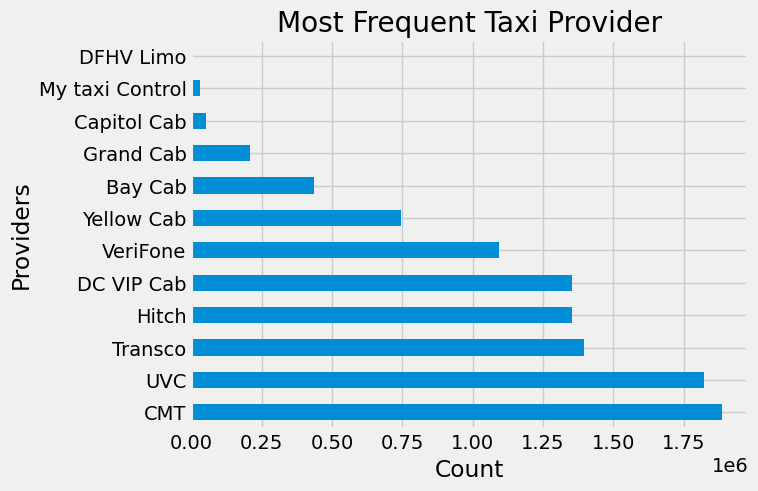

In [39]:
#plotting the Taxi Providers
ax = df['ProviderName'].value_counts().plot(kind='barh', title='Most Frequent Taxi Provider')
ax.set_xlabel('Count')
ax.set_ylabel('Providers')
plt.show()

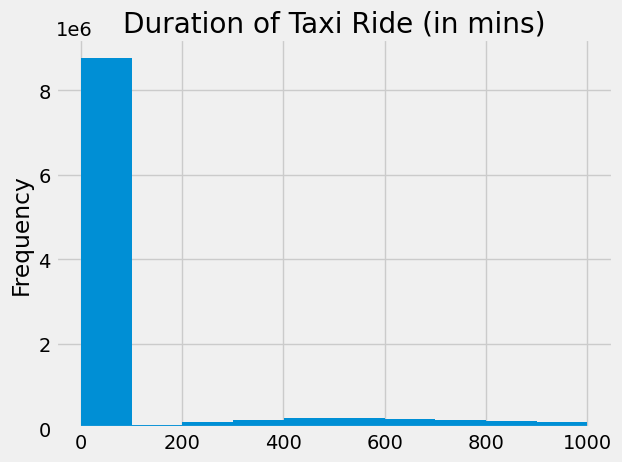

In [40]:
ax_2 = df['Duration'].plot(kind='hist', title='Duration of Taxi Ride (in mins)')  
ax_2.set_ylabel('Frequency')

plt.show()

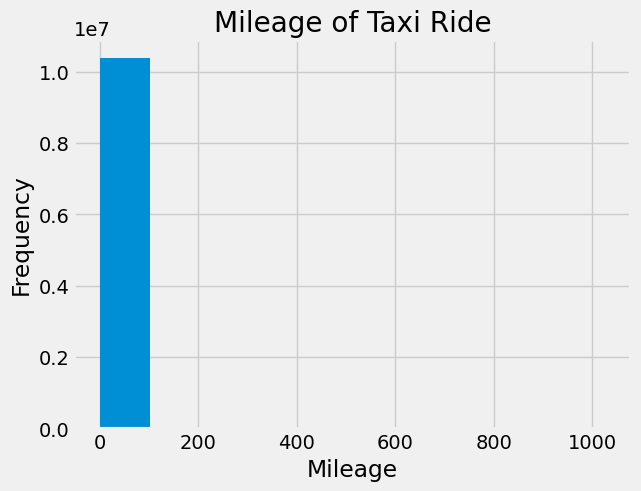

In [41]:
ax_2 = df['Mileage'].plot(kind='hist', title='Mileage of Taxi Ride')     #outliers removed
ax_2.set_xlabel('Mileage')
ax_2.set_ylabel('Frequency')

plt.show()

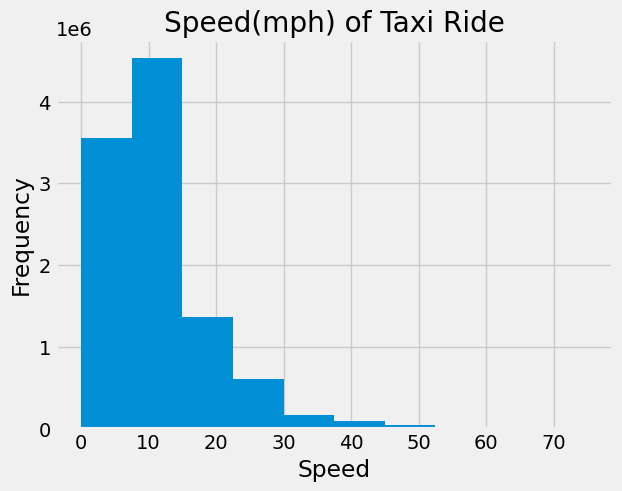

In [42]:
ax_2 = df['Speed'].plot(kind='hist', title='Speed(mph) of Taxi Ride')     #outliers removed
ax_2.set_xlabel('Speed')
ax_2.set_ylabel('Frequency')

plt.show()

#### Multivariate Analysis

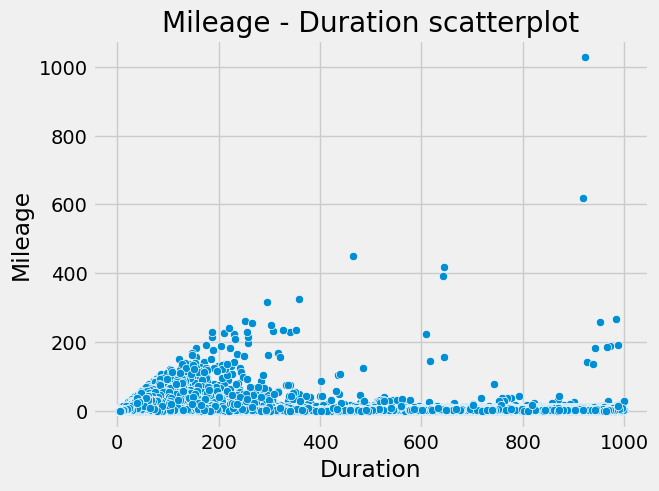

In [43]:
sns.scatterplot(x='Duration', y='Mileage', data=df)
plt.title('Mileage - Duration scatterplot')
plt.show()

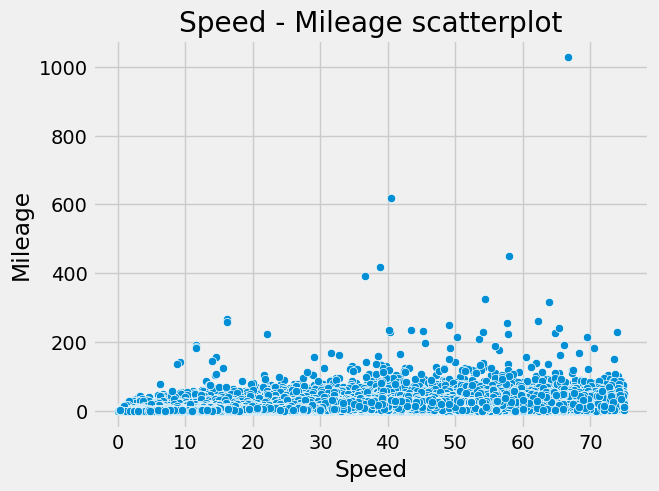

In [44]:
sns.scatterplot(x='Speed', y='Mileage', data=df)
plt.title('Speed - Mileage scatterplot')
plt.show()

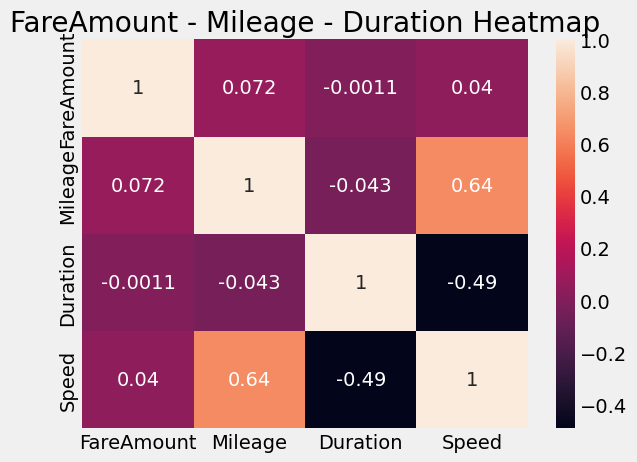

In [49]:
df_corr = df[['FareAmount', 'Mileage', 'Duration', 'Speed']].corr()
sns.heatmap(df_corr, annot=True)
plt.title('FareAmount - Mileage - Duration Heatmap')
plt.show()

## <span style="color: Orange;"> Machine Learning </span>

## <span style="color: Orange;"> Deep Learning </span>


## <span style="color: Orange;"> Results and Discussion </span>

The exploratory analysis of the taxi ride dataset yielded several key insights into the operational dynamics and customer trends within the taxi service industry.

1.Operational Insights: The analysis revealed patterns in metrics such as fare amount, mileage, and ride duration, providing valuable insights into the operational efficiency of taxi services. Understanding these patterns can inform strategic decision-making, such as optimizing route planning, managing fleet operations, and allocating resources effectively.

2.Customer Trends: By examining customer trends and preferences, the analysis identified opportunities for improving service delivery and enhancing customer satisfaction. Insights into factors influencing customer behavior, such as payment preferences and tipping habits, can guide the development of personalized services and promotional strategies.

3.Correlation Analysis: Correlation analysis highlighted relationships between key variables, offering a deeper understanding of their interactions. For example, the correlation between fare amount and mileage may indicate pricing structures or fare calculation methods used by taxi providers.

4.Outlier Detection: The identification and removal of outliers ensured the integrity of the dataset for further analysis. Addressing outliers in metrics such as ride duration and mileage helps mitigate the impact of anomalous data points on the overall analysis results.

5.Recommendations for Improvement: Based on the insights gained from the analysis, several recommendations can be made to enhance operational efficiency and customer satisfaction within the taxi service industry. These include optimizing route planning, implementing dynamic pricing strategies, providing driver training and incentives, enhancing customer engagement, and investing in technology solutions.

Overall, the results of the exploratory analysis provide a foundation for informed decision-making and strategic planning within the taxi service industry. By leveraging data-driven insights, taxi providers can optimize their operations, improve service quality, and ultimately deliver a better experience for customers. Continued monitoring and analysis of key metrics will be essential to adapt to changing market dynamics and maintain competitiveness in the industry.


## <span style="color: Orange;"> Conclusion </span>

In conclusion, the exploratory analysis of the taxi ride dataset has provided valuable insights into the operational dynamics and customer trends within the taxi service industry. Through data manipulation, visualization, and correlation analysis, we have identified key factors influencing metrics such as fare amount, mileage, and ride duration. Additionally, the removal of outliers has ensured the integrity of the dataset for further analysis. The pairplot visualization has offered a comprehensive view of pairwise relationships among the variables of interest, facilitating a deeper understanding of their interactions.

Based on these findings, several recommendations can be made to enhance operational efficiency and customer satisfaction within the taxi service industry:

Optimized Route Planning: Utilize insights from the analysis to optimize route planning and minimize ride duration, thereby reducing costs and improving customer experience.

Dynamic Pricing Strategies: Implement dynamic pricing strategies based on factors such as mileage, duration, and demand patterns to maximize revenue while remaining competitive.

Driver Training and Incentives: Provide driver training programs and incentives aimed at improving service quality, ensuring a positive experience for passengers.

Enhanced Customer Engagement: Leverage insights from customer trends to personalize services, offer promotions, and enhance overall customer engagement.

Investment in Technology: Invest in technology solutions such as GPS tracking, real-time analytics, and mobile applications to streamline operations and improve communication with passengers.

By incorporating these recommendations into their operations, taxi providers can achieve greater efficiency, profitability, and customer satisfaction, positioning themselves for success in a competitive market landscape. Additionally, continued analysis and monitoring of key metrics will be essential to adapt to changing market dynamics and evolving customer preferences in the future.

